In [1]:
# ── LIBRERÍAS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

# ── CHECKPOINT ─────────────────────────────────────────────
df         = pd.read_parquet(Path('../data/sp500_clean.parquet'))
last_price = pd.read_parquet(Path('../data/last_price_by_symbol.parquet'))

print(f"✅ Checkpoint cargado")
print(f"   Filas     : {len(df):,}")
print(f"   Símbolos  : {df['symbol'].nunique()}")
print(f"   Rango     : {df['date'].min().date()} → {df['date'].max().date()}")

✅ Checkpoint cargado
   Filas     : 7,237,112
   Símbolos  : 1284
   Rango     : 1990-01-02 → 2026-01-30


In [19]:
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════
# PARÁMETROS
# ══════════════════════════════════════════════════════════
LOOKBACK     = 60
N_ASSETS     = 20
INITIAL_CASH = 100_000
COMMISSION   = 0.001

# ══════════════════════════════════════════════════════════
# PIVOTS
# ══════════════════════════════════════════════════════════
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()

print(f"✅ Pivot precios : {close_pivot.shape[0]} fechas × {close_pivot.shape[1]} símbolos")
print(f"✅ Pivot sp500   : {sp500_pivot.shape[0]} fechas × {sp500_pivot.shape[1]} símbolos")

# ══════════════════════════════════════════════════════════
# SEÑAL DE MOMENTUM: (P_t / P_{t-60}) - 1
# ══════════════════════════════════════════════════════════
momentum = close_pivot / close_pivot.shift(LOOKBACK) - 1
first_signal_date = momentum.dropna(how='all').index[0]

print(f"✅ Primera señal disponible: {pd.Timestamp(first_signal_date).date()}")

# ══════════════════════════════════════════════════════════
# FECHAS DE REBALANCEO
# signal_date = último día bursátil del mes (T)
# exec_date   = siguiente día bursátil (T+1)
# ══════════════════════════════════════════════════════════
all_dates   = close_pivot.index
valid_dates = all_dates[all_dates >= first_signal_date]

signal_dates = (
    pd.Series(valid_dates)
    .groupby([pd.Series(valid_dates).dt.year,
              pd.Series(valid_dates).dt.month])
    .last()
    .values
)

rebal_pairs = []
for sd in signal_dates:
    sd     = pd.Timestamp(sd)
    future = all_dates[all_dates > sd]
    if len(future) > 0:
        rebal_pairs.append((sd, pd.Timestamp(future[0])))

print(f"✅ Total rebalanceos : {len(rebal_pairs)}")
print(f"   Primero : {rebal_pairs[0][0].date()} → ejecuta {rebal_pairs[0][1].date()}")
print(f"   Último  : {rebal_pairs[-1][0].date()} → ejecuta {rebal_pairs[-1][1].date()}")

# ══════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════
def get_close(symbol, date):
    """Precio close ajustado en 'date'. None si no cotiza ese día."""
    if symbol in close_pivot.columns and date in close_pivot.index:
        p = close_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    """
    Último precio válido disponible hasta 'before_date' inclusive.
    Usado para valorar/vender activos que han desaparecido.
    Devuelve 0.0 si no hay ningún precio (quiebra total).
    """
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# ENGINE DEL BACKTEST
# ══════════════════════════════════════════════════════════
portfolio         = {}   # {symbol: valor_en_euros}
last_rebal_price  = {}   # {symbol: precio_en_el_ultimo_rebalanceo}
cash              = INITIAL_CASH
nav_history       = []
trade_log         = []
holdings_history = []

for signal_date, exec_date in rebal_pairs:

    if signal_date not in momentum.index:
        continue

    # ── 0. MARK-TO-MARKET ─────────────────────────────────
    # Actualizamos el valor en euros de cada posición antes
    # de cualquier operación
    for symbol in list(portfolio.keys()):
        old_price = last_rebal_price[symbol]
        new_price = get_close(symbol, exec_date)

        if new_price is None:
            # Activo desaparecido → valoramos al último precio conocido
            new_price = get_last_known_close(symbol, exec_date)

        ret = (new_price / old_price) if old_price > 0 else 0.0
        portfolio[symbol]        *= ret
        last_rebal_price[symbol]  = new_price

    # ── 1. UNIVERSO VÁLIDO EN T (signal_date) ─────────────
    # ✅ Filtro aplicado en T, no en T+1 → evita lookahead bias
    scores = momentum.loc[signal_date].dropna()

    if signal_date in sp500_pivot.index:
        sp500_today   = sp500_pivot.loc[signal_date]
        valid_symbols = sp500_today[sp500_today == 1].index
    else:
        valid_symbols = pd.Index([])

    # Filtramos por: (1) en SP500 en T, (2) con precio válido en T+1
    valid_scores = scores[
        scores.index.isin(valid_symbols) &
        scores.index.map(lambda s: get_close(s, exec_date) is not None)
    ]

    top20         = set(valid_scores.nlargest(N_ASSETS).index)
    portfolio_set = set(portfolio.keys())

    # ── 2. CLASIFICACIÓN DE GRUPOS ─────────────────────────
    group_a = portfolio_set & top20    # Mantener  → no hacer nada
    group_b = portfolio_set - top20    # Vender    → 100%
    group_c = top20 - portfolio_set    # Comprar   → nuevas entradas

    # ── PASO 1: GRUPO A — no se hace nada ─────────────────

    # ── PASO 2: GRUPO B — vender el 100% ──────────────────
    for symbol in group_b:
        capital_value = portfolio[symbol]
        price         = last_rebal_price[symbol]  # ya actualizado en MTM
        commission    = capital_value * COMMISSION
        cash         += capital_value - commission

        trade_log.append({
            'date'      : exec_date,
            'symbol'    : symbol,
            'action'    : 'SELL',
            'capital'   : capital_value,
            'price'     : price,
            'commission': commission,
        })

        del portfolio[symbol]
        del last_rebal_price[symbol]

    # ── PASO 3: GRUPO C — comprar con todo el cash ────────
    n_to_buy = len(group_c)

    if n_to_buy > 0 and cash > 0:
        capital_per_asset = cash / n_to_buy

        for symbol in group_c:
            price = get_close(symbol, exec_date)

            if price is None or price <= 0:
                # No disponible → ese tramo queda en cash idle
                continue

            # capital_per_asset = inversión_real + comisión
            # → inversión_real = capital_per_asset / (1 + COMMISSION)
            invested_capital = capital_per_asset / (1 + COMMISSION)
            commission       = invested_capital * COMMISSION

            cash -= capital_per_asset  # descontamos el total (inversión + comisión)

            portfolio[symbol]        = invested_capital
            last_rebal_price[symbol] = price

            trade_log.append({
                'date'      : exec_date,
                'symbol'    : symbol,
                'action'    : 'BUY',
                'capital'   : invested_capital,
                'price'     : price,
                'commission': commission,
            })

    # Corrección de precisión numérica (floating point)
    cash = max(cash, 0.0)

    # ── NAV TRAS REBALANCEO ────────────────────────────────
    nav_after = cash + sum(portfolio.values())

    nav_history.append({
        'date'        : exec_date,
        'nav'         : nav_after,
        'cash'        : cash,
        'n_positions' : len(portfolio),
        'n_bought'    : len(group_c),
        'n_sold'      : len(group_b),
        'n_kept'      : len(group_a),
        'pct_invested': (nav_after - cash) / nav_after * 100 if nav_after > 0 else 0,
    })
    # ── GUARDAR FOTO DE LA CARTERA ─────────────────────────
    current_weights = {'date': exec_date}
    for sym, cap in portfolio.items():
        current_weights[sym] = (cap / nav_after) * 100  # Guardamos el peso en %
    holdings_history.append(current_weights)

# ══════════════════════════════════════════════════════════
# RESULTADOS
# ══════════════════════════════════════════════════════════
nav_df   = pd.DataFrame(nav_history)
trade_df = pd.DataFrame(trade_log)

print("\n" + "═" * 50)
print("📊 RESUMEN DEL BACKTEST")
print("═" * 50)
print(f"  Capital inicial    : {INITIAL_CASH:>12,.2f} €")
print(f"  NAV final          : {nav_df['nav'].iloc[-1]:>12,.2f} €")
print(f"  Retorno total      : {(nav_df['nav'].iloc[-1] / INITIAL_CASH - 1) * 100:>11.2f} %")
print(f"  Total operaciones  : {len(trade_df):>12,}")
print(f"  Comisiones totales : {trade_df['commission'].sum():>11,.2f} €")
print(f"\n  Primeras filas del NAV:")
print(nav_df.head(10).to_string(index=False))

✅ Pivot precios : 9027 fechas × 1283 símbolos
✅ Pivot sp500   : 9027 fechas × 1283 símbolos
✅ Primera señal disponible: 1990-06-22
✅ Total rebalanceos : 427
   Primero : 1990-06-29 → ejecuta 1990-07-02
   Último  : 2025-12-31 → ejecuta 2026-01-02

══════════════════════════════════════════════════
📊 RESUMEN DEL BACKTEST
══════════════════════════════════════════════════
  Capital inicial    :   100,000.00 €
  NAV final          : 7,715,525.10 €
  Retorno total      :     7615.53 %
  Total operaciones  :       10,636
  Comisiones totales : 1,176,706.77 €

  Primeras filas del NAV:
      date         nav   cash  n_positions  n_bought  n_sold  n_kept  pct_invested
1990-07-02  99900.0999 0.0000           20        20       0       0      100.0000
1990-08-01  93171.6899 0.0000           20        15      15       5      100.0000
1990-09-04  84467.0347 0.0000           20        16      16       4      100.0000
1990-10-01  81874.6223 0.0000           20         9       9      11      100.000


════════════════════════════════════════
🏢 CARTERA ACTUAL (2026-01-02)
════════════════════════════════════════
WDC     10.91 %
MU       6.57 %
TER      6.40 %
ALB      6.02 %
WBD      5.58 %
GOOGL    4.88 %
LLY      4.86 %
SNDK     4.70 %
FCX      4.28 %
LUV      4.28 %
DLTR     4.28 %
ISRG     4.28 %
GM       4.28 %
JBHT     4.28 %
EXPE     4.28 %
DG       4.28 %
EPAM     4.28 %
LVS      4.28 %
REGN     3.72 %
CAH      3.56 %
Total invertido: 100.00 %


C:\Users\User\AppData\Local\Temp\ipykernel_22576\2082095169.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


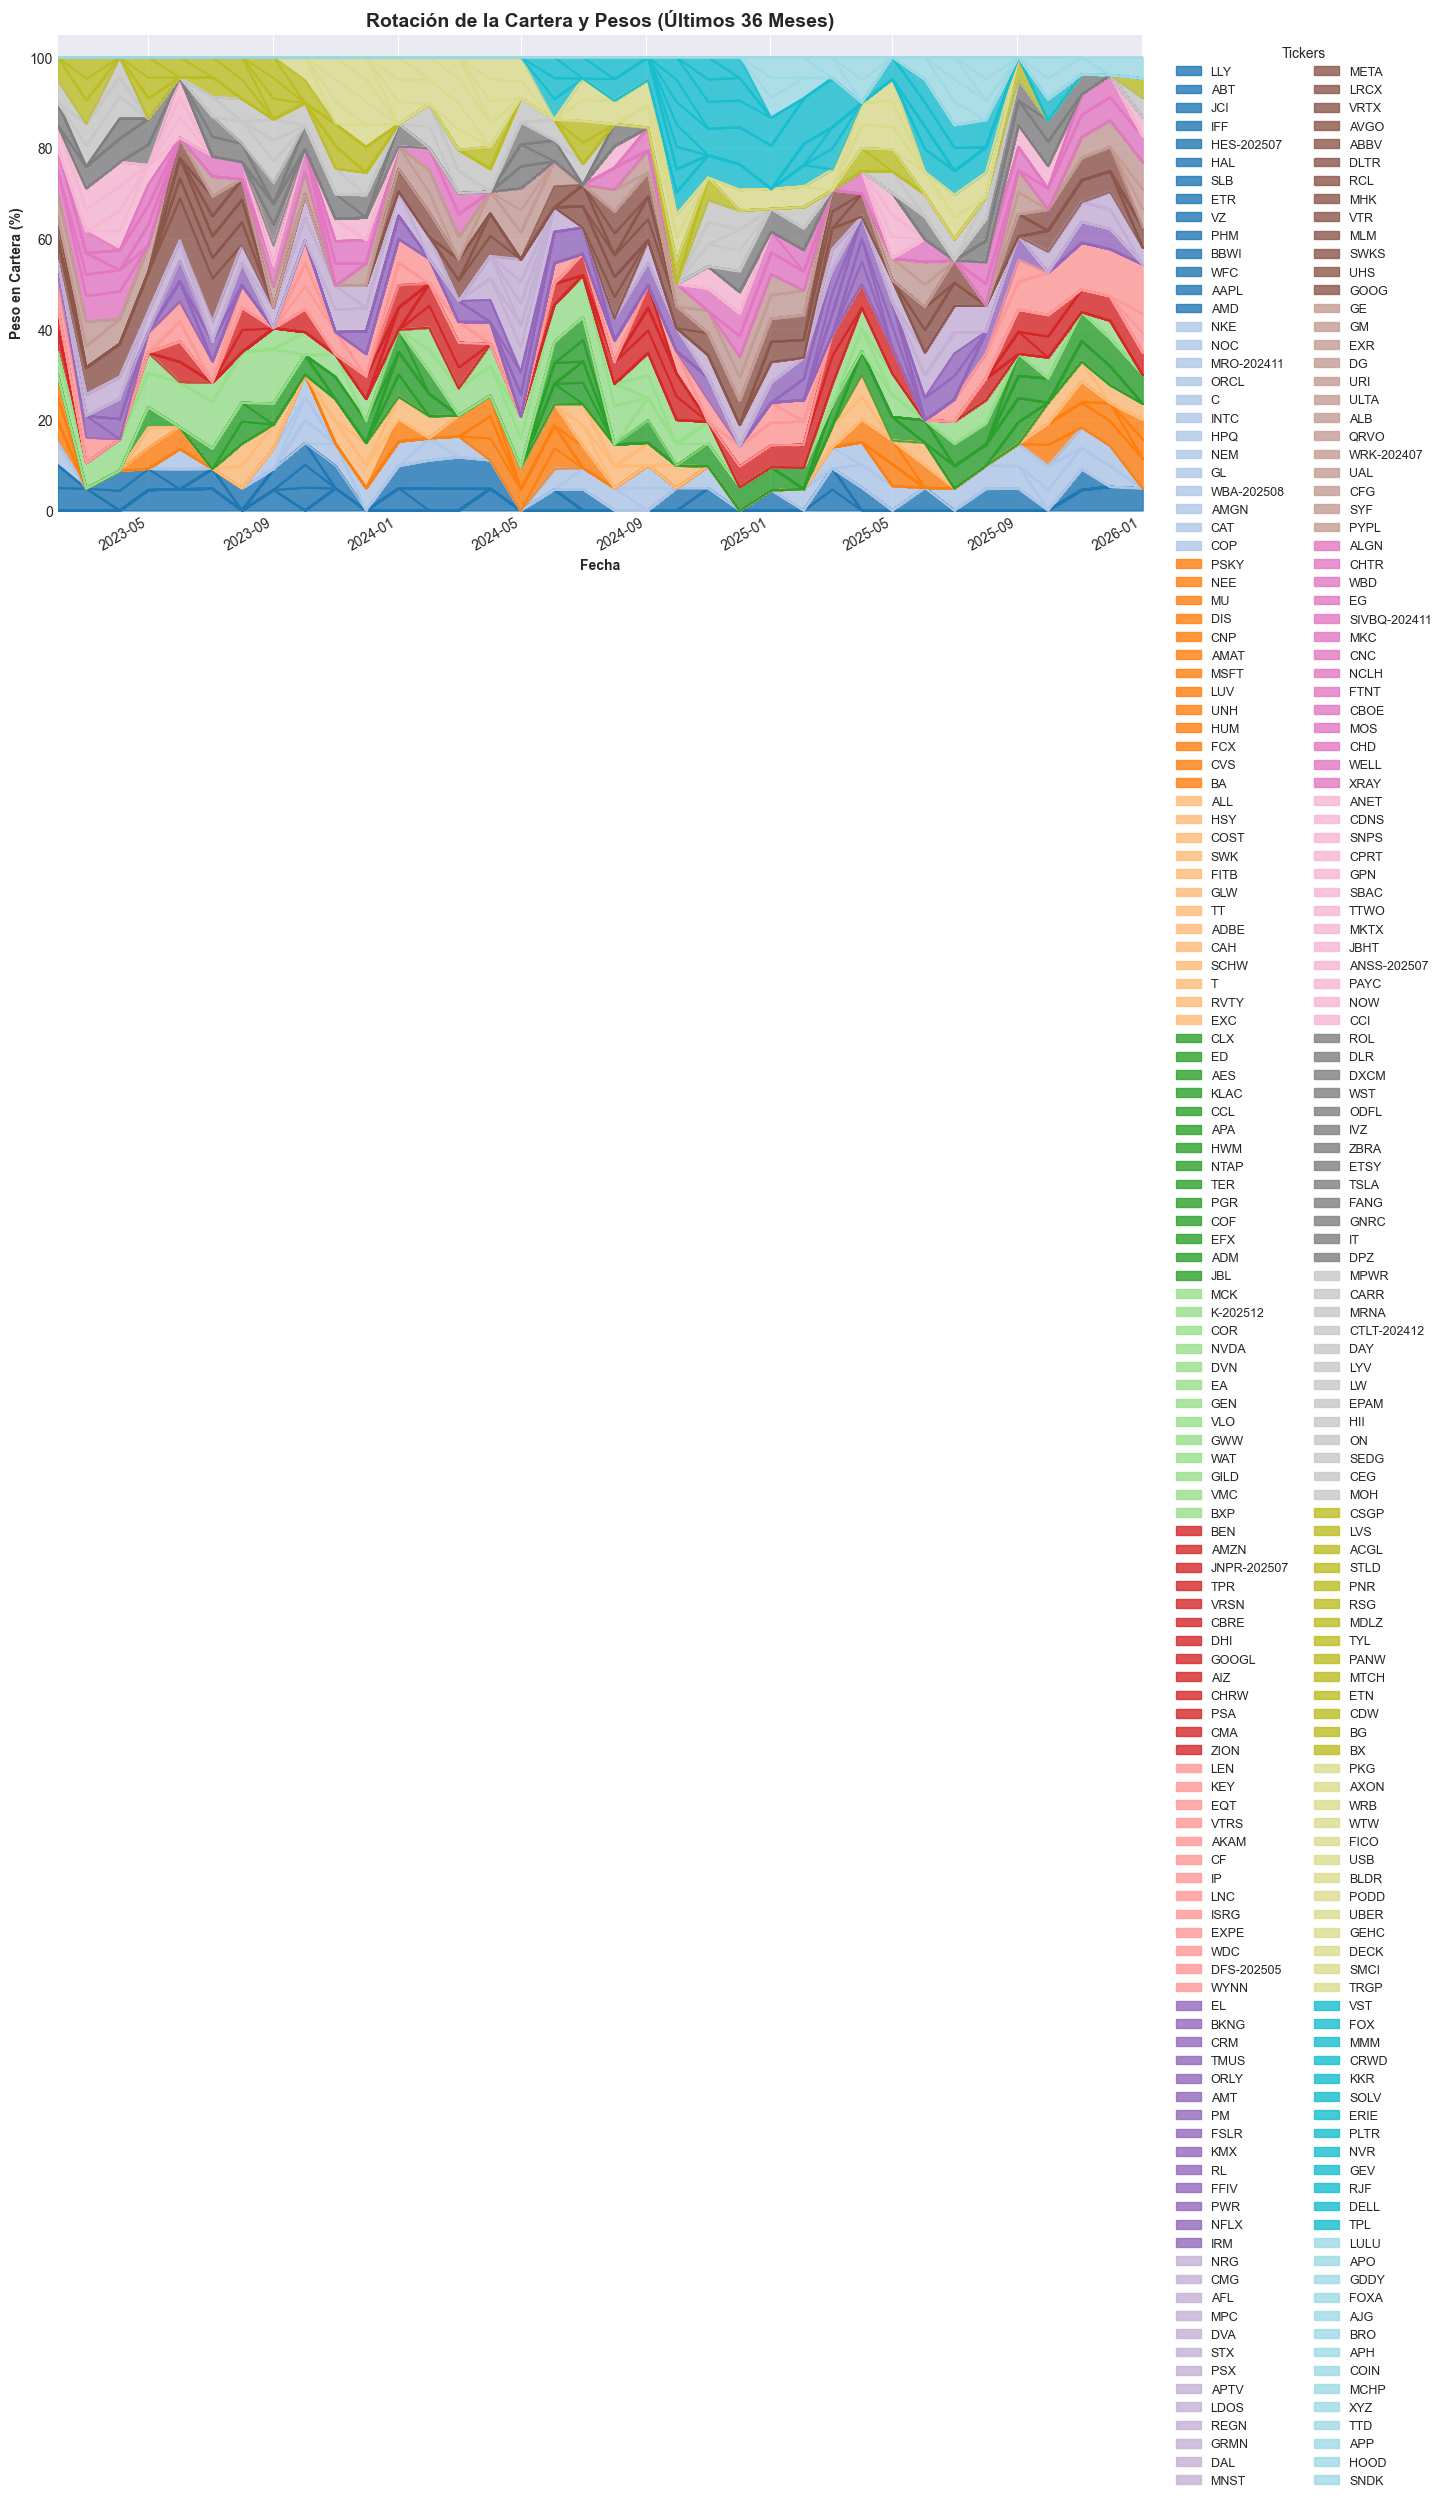

In [20]:
import matplotlib.pyplot as plt

# 1. Convertir el historial en un DataFrame
holdings_df = pd.DataFrame(holdings_history).set_index('date').fillna(0)

# 2. Imprimir la última cartera (La "Foto" actual)
ultima_cartera = holdings_df.iloc[-1]
ultima_cartera = ultima_cartera[ultima_cartera > 0].sort_values(ascending=False)

print("\n" + "═" * 40)
print(f"🏢 CARTERA ACTUAL ({holdings_df.index[-1].date()})")
print("═" * 40)
print(ultima_cartera.to_string(float_format="{:.2f} %".format))
print(f"Total invertido: {ultima_cartera.sum():.2f} %")

# 3. Gráfico de rotación (Últimos 3 años para que sea legible)
# Filtramos los últimos 36 meses
df_plot = holdings_df.iloc[-36:]
# Eliminamos las columnas de empresas que no han estado en la cartera en estos 3 años
df_plot = df_plot.loc[:, (df_plot != 0).any(axis=0)]

# Pintar el gráfico de áreas
ax = df_plot.plot.area(figsize=(14, 7), colormap='tab20', alpha=0.8, legend=False)

plt.title('Rotación de la Cartera y Pesos (Últimos 36 Meses)', fontweight='bold', fontsize=14)
plt.ylabel('Peso en Cartera (%)', fontweight='bold')
plt.xlabel('Fecha', fontweight='bold')
plt.margins(x=0, y=0) # Quita los espacios en blanco a los lados

# Colocar la leyenda fuera del gráfico para que no tape los datos
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=2, title="Tickers")
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════
# PARÁMETROS
# ══════════════════════════════════════════════════════════
LOOKBACK     = 60
N_ASSETS     = 20
INITIAL_CASH = 100_000
COMMISSION   = 0.001
RF_ANNUAL    = 0.03  # tasa libre de riesgo anual para Sharpe/Sortino

# ══════════════════════════════════════════════════════════
# PIVOTS
# ══════════════════════════════════════════════════════════
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

close_pivot = df.pivot_table(index='date', columns='symbol', values='close').sort_index()
sp500_pivot = df.pivot_table(index='date', columns='symbol', values='in_sp500').fillna(0).sort_index()

# ══════════════════════════════════════════════════════════
# SEÑAL DE MOMENTUM
# ══════════════════════════════════════════════════════════
momentum = close_pivot / close_pivot.shift(LOOKBACK) - 1
first_signal_date = momentum.dropna(how='all').index[0]

print(f"✅ Primera señal disponible: {pd.Timestamp(first_signal_date).date()}")

# ══════════════════════════════════════════════════════════
# FECHAS DE REBALANCEO
# ══════════════════════════════════════════════════════════
all_dates   = close_pivot.index
valid_dates = all_dates[all_dates >= first_signal_date]

signal_dates = (
    pd.Series(valid_dates)
    .groupby([pd.Series(valid_dates).dt.year,
              pd.Series(valid_dates).dt.month])
    .last()
    .values
)

rebal_pairs = []
for sd in signal_dates:
    sd     = pd.Timestamp(sd)
    future = all_dates[all_dates > sd]
    if len(future) > 0:
        rebal_pairs.append((sd, pd.Timestamp(future[0])))

print(f"✅ Total rebalanceos : {len(rebal_pairs)}")

# ══════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════
def get_close(symbol, date):
    if symbol in close_pivot.columns and date in close_pivot.index:
        p = close_pivot.at[date, symbol]
        if pd.notna(p) and p > 0:
            return float(p)
    return None

def get_last_known_close(symbol, before_date):
    if symbol in close_pivot.columns:
        past = close_pivot[symbol].loc[:before_date].dropna()
        if not past.empty:
            return float(past.iloc[-1])
    return 0.0

# ══════════════════════════════════════════════════════════
# ENGINE
# ══════════════════════════════════════════════════════════
portfolio        = {}
last_rebal_price = {}
cash             = INITIAL_CASH
nav_history      = []
trade_log        = []
composition_log  = []   # ← NUEVO: composición y pesos por rebalanceo

for signal_date, exec_date in rebal_pairs:

    if signal_date not in momentum.index:
        continue

    # ── 0. MARK-TO-MARKET ─────────────────────────────────
    for symbol in list(portfolio.keys()):
        old_price = last_rebal_price[symbol]
        new_price = get_close(symbol, exec_date)
        if new_price is None:
            new_price = get_last_known_close(symbol, exec_date)
        ret = (new_price / old_price) if old_price > 0 else 0.0
        portfolio[symbol]        *= ret
        last_rebal_price[symbol]  = new_price

    # ── 1. UNIVERSO VÁLIDO EN T ────────────────────────────
    scores = momentum.loc[signal_date].dropna()

    if signal_date in sp500_pivot.index:
        sp500_today   = sp500_pivot.loc[signal_date]
        valid_symbols = sp500_today[sp500_today == 1].index
    else:
        valid_symbols = pd.Index([])

    valid_scores = scores[
        scores.index.isin(valid_symbols) &
        scores.index.map(lambda s: get_close(s, exec_date) is not None)
    ]

    top20         = set(valid_scores.nlargest(N_ASSETS).index)
    portfolio_set = set(portfolio.keys())

    group_a = portfolio_set & top20
    group_b = portfolio_set - top20
    group_c = top20 - portfolio_set

    # ── PASO 2: VENDER GRUPO B ─────────────────────────────
    for symbol in group_b:
        capital_value = portfolio[symbol]
        price         = last_rebal_price[symbol]
        commission    = capital_value * COMMISSION
        cash         += capital_value - commission

        trade_log.append({
            'date': exec_date, 'symbol': symbol, 'action': 'SELL',
            'capital': capital_value, 'price': price, 'commission': commission,
        })
        del portfolio[symbol]
        del last_rebal_price[symbol]

    # ── PASO 3: COMPRAR GRUPO C ────────────────────────────
    n_to_buy = len(group_c)

    if n_to_buy > 0 and cash > 0:
        capital_per_asset = cash / n_to_buy

        for symbol in group_c:
            price = get_close(symbol, exec_date)
            if price is None or price <= 0:
                continue

            invested_capital = capital_per_asset / (1 + COMMISSION)
            commission       = invested_capital * COMMISSION
            cash            -= capital_per_asset

            portfolio[symbol]        = invested_capital
            last_rebal_price[symbol] = price

            trade_log.append({
                'date': exec_date, 'symbol': symbol, 'action': 'BUY',
                'capital': invested_capital, 'price': price, 'commission': commission,
            })

    cash = max(cash, 0.0)

    # ── NAV Y COMPOSICIÓN ─────────────────────────────────
    nav_after = cash + sum(portfolio.values())

    nav_history.append({
        'date': exec_date, 'nav': nav_after, 'cash': cash,
        'n_positions': len(portfolio), 'n_bought': len(group_c),
        'n_sold': len(group_b), 'n_kept': len(group_a),
        'pct_invested': (nav_after - cash) / nav_after * 100 if nav_after > 0 else 0,
    })

    # ── REGISTRO DE COMPOSICIÓN ────────────────────────────
    for symbol, capital in portfolio.items():
        composition_log.append({
            'date'       : exec_date,
            'symbol'     : symbol,
            'capital'    : capital,
            'weight_pct' : capital / nav_after * 100 if nav_after > 0 else 0,
            'nav'        : nav_after,
        })
    # También registramos el cash como posición
    composition_log.append({
        'date'      : exec_date,
        'symbol'    : '_CASH',
        'capital'   : cash,
        'weight_pct': cash / nav_after * 100 if nav_after > 0 else 0,
        'nav'       : nav_after,
    })

# ── DATAFRAMES FINALES ─────────────────────────────────────
nav_df   = pd.DataFrame(nav_history)
trade_df = pd.DataFrame(trade_log)
comp_df  = pd.DataFrame(composition_log)

print("\n" + "═" * 50)
print("📊 RESUMEN DEL BACKTEST")
print("═" * 50)
print(f"  Capital inicial    : {INITIAL_CASH:>12,.2f} €")
print(f"  NAV final          : {nav_df['nav'].iloc[-1]:>12,.2f} €")
print(f"  Retorno total      : {(nav_df['nav'].iloc[-1] / INITIAL_CASH - 1) * 100:>11.2f} %")
print(f"  Total operaciones  : {len(trade_df):>12,}")
print(f"  Comisiones totales : {trade_df['commission'].sum():>11,.2f} €")
print(f"\n  Muestra comp_df:")
print(comp_df[comp_df['symbol'] != '_CASH'].head(10).to_string(index=False))

✅ Primera señal disponible: 1990-06-22
✅ Total rebalanceos : 427

══════════════════════════════════════════════════
📊 RESUMEN DEL BACKTEST
══════════════════════════════════════════════════
  Capital inicial    :   100,000.00 €
  NAV final          : 7,715,525.10 €
  Retorno total      :     7615.53 %
  Total operaciones  :       10,636
  Comisiones totales : 1,176,706.77 €

  Muestra comp_df:
      date     symbol   capital  weight_pct        nav
1990-07-02        CAG 4995.0050      5.0000 99900.0999
1990-07-02 BEV-200603 4995.0050      5.0000 99900.0999
1990-07-02 STJ-201701 4995.0050      5.0000 99900.0999
1990-07-02        LOW 4995.0050      5.0000 99900.0999
1990-07-02        SCI 4995.0050      5.0000 99900.0999
1990-07-02 MAI-199506 4995.0050      5.0000 99900.0999
1990-07-02        MSI 4995.0050      5.0000 99900.0999
1990-07-02        NWL 4995.0050      5.0000 99900.0999
1990-07-02         PG 4995.0050      5.0000 99900.0999
1990-07-02        TAP 4995.0050      5.0000 99900.09

In [22]:
# ══════════════════════════════════════════════════════════
# MÉTRICAS DE PERFORMANCE
# ══════════════════════════════════════════════════════════

nav_series = nav_df.set_index('date')['nav'].sort_index()

# Retornos mensuales
monthly_returns = nav_series.pct_change().dropna()

# ── CAGR ──────────────────────────────────────────────────
n_years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
cagr    = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1 / n_years) - 1

# ── VOLATILIDAD ANUALIZADA ────────────────────────────────
vol_annual = monthly_returns.std() * np.sqrt(12)

# ── SHARPE ────────────────────────────────────────────────
rf_monthly = (1 + RF_ANNUAL) ** (1/12) - 1
excess_ret = monthly_returns - rf_monthly
sharpe     = (excess_ret.mean() / excess_ret.std()) * np.sqrt(12)

# ── SORTINO ───────────────────────────────────────────────
downside_ret  = monthly_returns[monthly_returns < rf_monthly]
downside_std  = downside_ret.std() * np.sqrt(12)
sortino       = (cagr - RF_ANNUAL) / downside_std if downside_std > 0 else np.nan

# ── MAX DRAWDOWN ──────────────────────────────────────────
rolling_max  = nav_series.cummax()
drawdown     = (nav_series - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Duración del max drawdown
dd_end   = drawdown.idxmin()
dd_start = nav_series[:dd_end].idxmax()
dd_days  = (dd_end - dd_start).days

# ── CALMAR RATIO ──────────────────────────────────────────
calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

# ── WIN RATE MENSUAL ──────────────────────────────────────
win_rate = (monthly_returns > 0).sum() / len(monthly_returns) * 100

# ── BEST / WORST MES ──────────────────────────────────────
best_month  = monthly_returns.max()
worst_month = monthly_returns.min()

# ── PROFIT FACTOR ─────────────────────────────────────────
gross_profits = monthly_returns[monthly_returns > 0].sum()
gross_losses  = monthly_returns[monthly_returns < 0].abs().sum()
profit_factor = gross_profits / gross_losses if gross_losses > 0 else np.nan

# ── PRINT ─────────────────────────────────────────────────
print("═" * 55)
print("📈 MÉTRICAS DE PERFORMANCE — MOMENTUM STRATEGY")
print("═" * 55)
print(f"  Período analizado    : {nav_series.index[0].date()} → {nav_series.index[-1].date()}")
print(f"  Años                 : {n_years:.1f}")
print(f"\n  {'RETORNO':}")
print(f"    CAGR               : {cagr * 100:>8.2f} %")
print(f"    Retorno total      : {(nav_series.iloc[-1]/nav_series.iloc[0]-1)*100:>8.2f} %")
print(f"    Mejor mes          : {best_month * 100:>8.2f} %")
print(f"    Peor mes           : {worst_month * 100:>8.2f} %")
print(f"    Win rate mensual   : {win_rate:>8.2f} %")
print(f"\n  {'RIESGO':}")
print(f"    Volatilidad anual  : {vol_annual * 100:>8.2f} %")
print(f"    Max Drawdown       : {max_drawdown * 100:>8.2f} %")
print(f"    Inicio MDD         : {dd_start.date()}")
print(f"    Fin MDD            : {dd_end.date()}")
print(f"    Duración MDD       : {dd_days} días")
print(f"\n  {'RATIOS':}")
print(f"    Sharpe (RF=3%)     : {sharpe:>8.2f}")
print(f"    Sortino (RF=3%)    : {sortino:>8.2f}")
print(f"    Calmar             : {calmar:>8.2f}")
print(f"    Profit Factor      : {profit_factor:>8.2f}")

═══════════════════════════════════════════════════════
📈 MÉTRICAS DE PERFORMANCE — MOMENTUM STRATEGY
═══════════════════════════════════════════════════════
  Período analizado    : 1990-07-02 → 2026-01-02
  Años                 : 35.5

  RETORNO
    CAGR               :    13.02 %
    Retorno total      :  7623.24 %
    Mejor mes          :    28.61 %
    Peor mes           :   -21.65 %
    Win rate mensual   :    59.86 %

  RIESGO
    Volatilidad anual  :    22.07 %
    Max Drawdown       :   -61.53 %
    Inicio MDD         : 2007-10-01
    Fin MDD            : 2009-03-02
    Duración MDD       : 518 días

  RATIOS
    Sharpe (RF=3%)     :     0.53
    Sortino (RF=3%)    :     0.70
    Calmar             :     0.21
    Profit Factor      :     1.67


In [26]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------------- ------- 1.3/1.6 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.0 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15689 sha256=2ad4ca59623920c303f21ecc5c2f4c7e53276ce8021292610a9ad9e7fde63d32
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\7e\62\f9\20d7dbb144b6f563edab8e3a7fda71d976870cd41972035cdd
Successfully built multitasking

   ---------------------------------------- 0/8 [pytz]
   ----- ---------------------------------- 1/8 [peewee]
   -------------

✅ SPY descargado: 1993-01-29 → 2025-12-31 (8,288 puntos)

═══════════════════════════════════════════════════════
📊 COMPARATIVA ESTRATEGIA vs SPY
═══════════════════════════════════════════════════════
  Métrica                  Estrategia          SPY
  ----------------------------------------------
  CAGR                         13.02%       10.67%
  Volatilidad anual            22.07%       14.73%
  Sharpe (RF=3%)                 0.53         0.56
  Max Drawdown                -61.53%      -55.19%


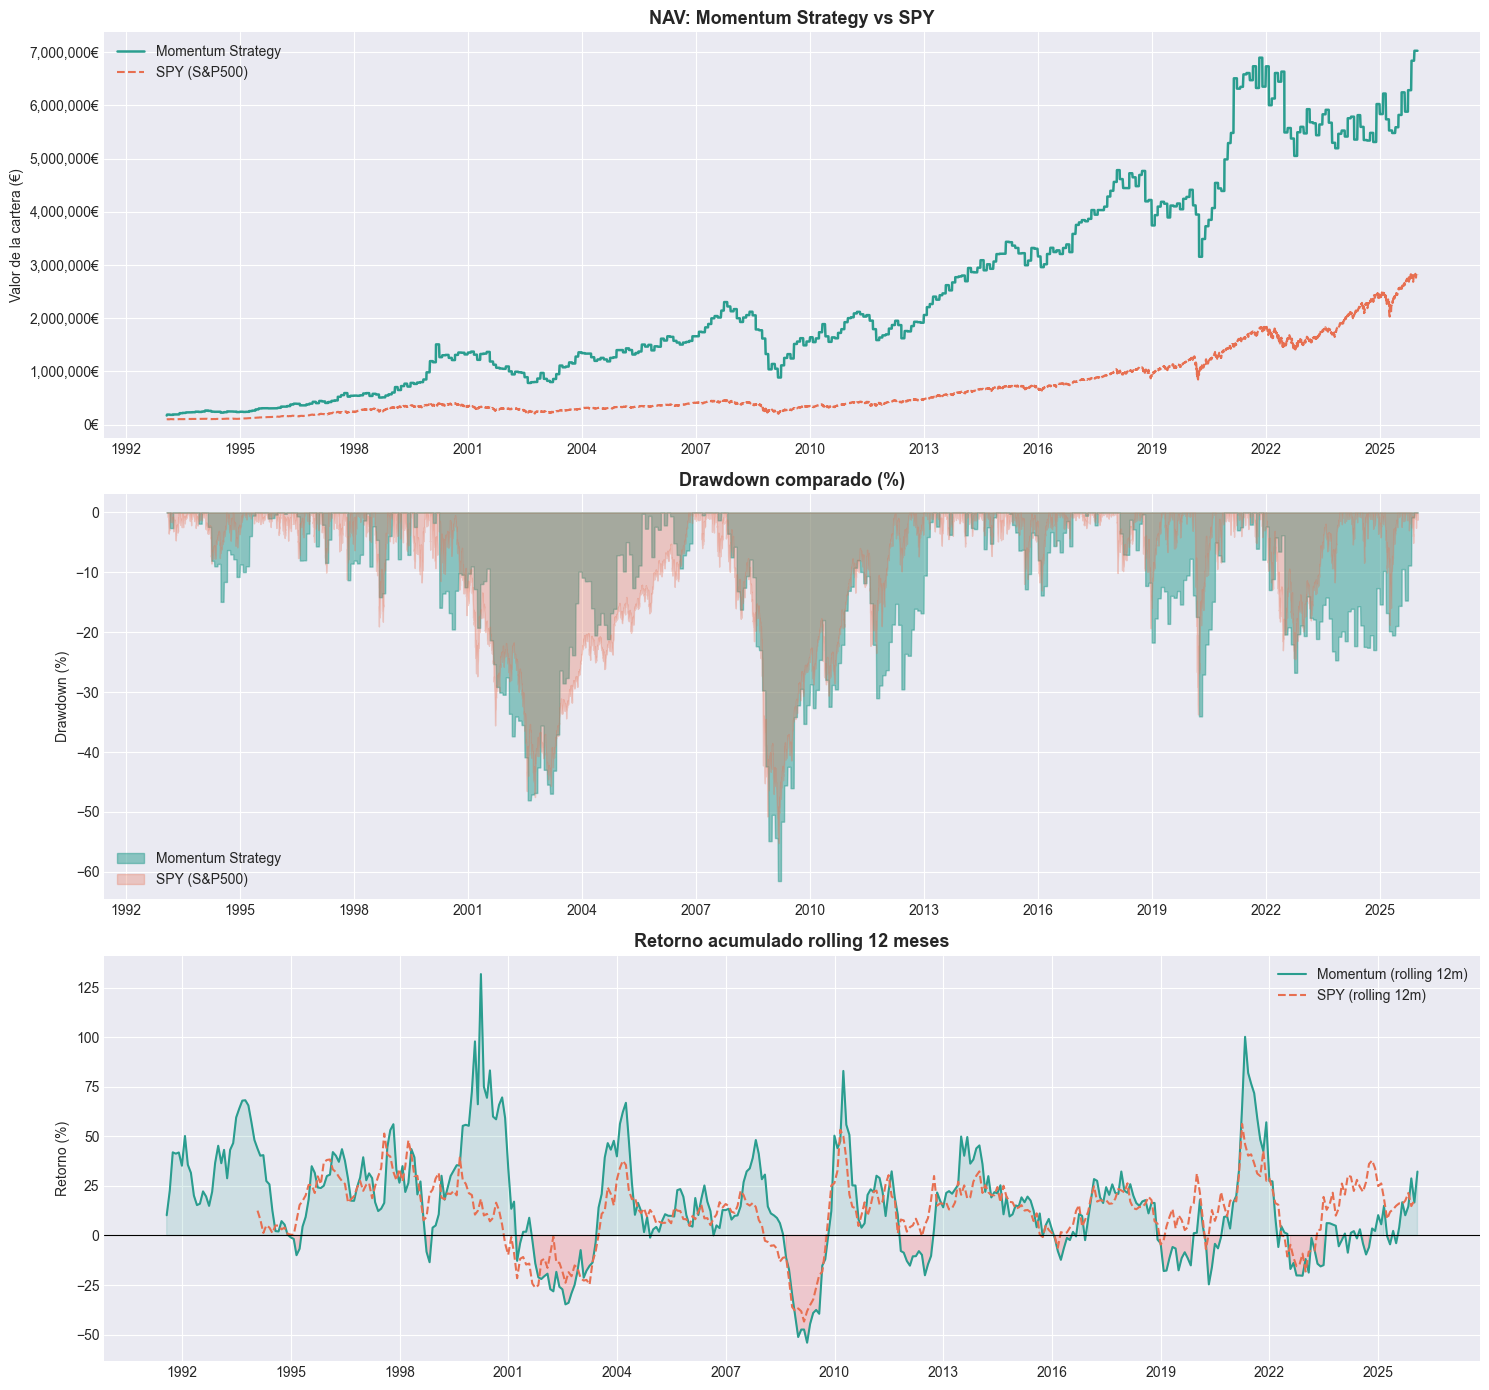

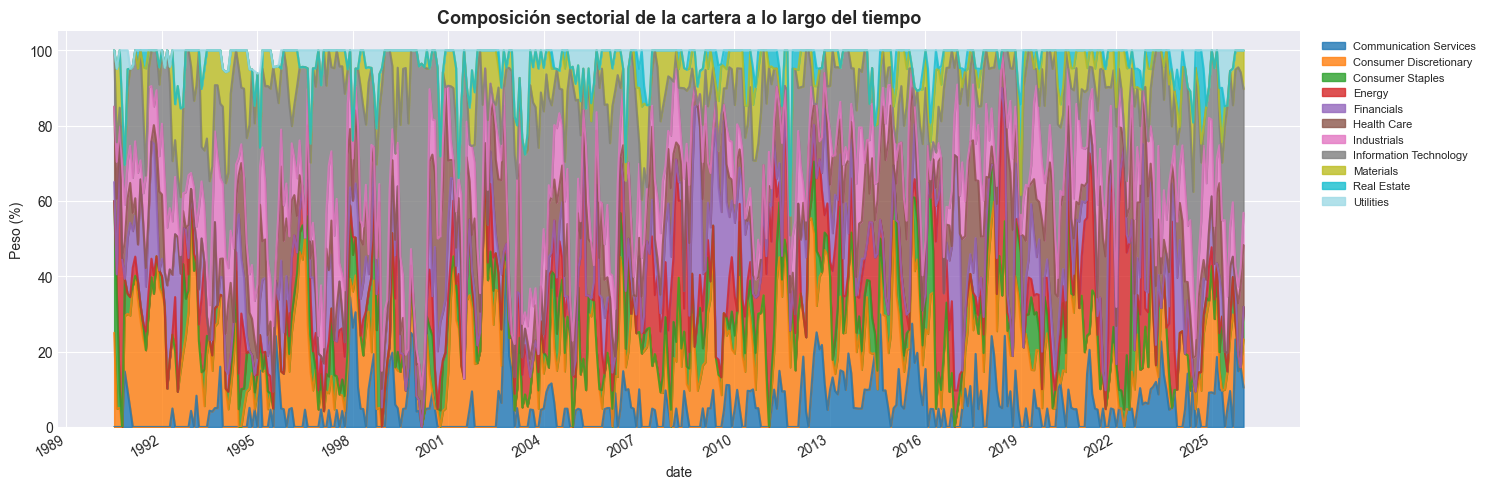

In [27]:
import yfinance as yf

# ══════════════════════════════════════════════════════════
# BENCHMARK: SPY desde Yahoo Finance
# ══════════════════════════════════════════════════════════
start_date = nav_df['date'].iloc[0]
end_date   = nav_df['date'].iloc[-1]

spy_raw   = yf.download('SPY', start=start_date, end=end_date, auto_adjust=True, progress=False)
spy_close = spy_raw['Close'].squeeze()
bm_series = spy_close / spy_close.iloc[0] * INITIAL_CASH

print(f"✅ SPY descargado: {bm_series.index[0].date()} → {bm_series.index[-1].date()} ({len(bm_series):,} puntos)")

# ══════════════════════════════════════════════════════════
# ALINEAR ESTRATEGIA CON EL ÍNDICE DIARIO DEL SPY
# ══════════════════════════════════════════════════════════
strat_series = nav_df.set_index('date')['nav'].reindex(bm_series.index, method='ffill')

# ══════════════════════════════════════════════════════════
# MÉTRICAS DEL BENCHMARK
# ══════════════════════════════════════════════════════════
rf_monthly     = (1 + RF_ANNUAL) ** (1/12) - 1
bm_monthly_ret = bm_series.resample('ME').last().pct_change().dropna()
bm_n_years     = (bm_series.index[-1] - bm_series.index[0]).days / 365.25
bm_cagr        = (bm_series.iloc[-1] / bm_series.iloc[0]) ** (1 / bm_n_years) - 1
bm_vol         = bm_monthly_ret.std() * np.sqrt(12)
bm_excess      = bm_monthly_ret - rf_monthly
bm_sharpe      = (bm_excess.mean() / bm_excess.std()) * np.sqrt(12)
bm_rolling_max = bm_series.cummax()
bm_drawdown    = (bm_series - bm_rolling_max) / bm_rolling_max
bm_max_dd      = bm_drawdown.min()

print("\n" + "═" * 55)
print("📊 COMPARATIVA ESTRATEGIA vs SPY")
print("═" * 55)
print(f"  {'Métrica':<22} {'Estrategia':>12} {'SPY':>12}")
print(f"  {'-'*46}")
print(f"  {'CAGR':<22} {cagr*100:>11.2f}% {bm_cagr*100:>11.2f}%")
print(f"  {'Volatilidad anual':<22} {vol_annual*100:>11.2f}% {bm_vol*100:>11.2f}%")
print(f"  {'Sharpe (RF=3%)':<22} {sharpe:>12.2f} {bm_sharpe:>12.2f}")
print(f"  {'Max Drawdown':<22} {max_drawdown*100:>11.2f}% {bm_max_dd*100:>11.2f}%")

# ══════════════════════════════════════════════════════════
# GRÁFICOS
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# ── Gráfico 1: NAV Estrategia vs SPY ──────────────────────
axes[0].plot(strat_series.index, strat_series,
             label='Momentum Strategy', color='#2a9d8f', linewidth=1.8)
axes[0].plot(bm_series.index, bm_series,
             label='SPY (S&P500)', color='#e76f51',
             linewidth=1.5, linestyle='--')
axes[0].set_title('NAV: Momentum Strategy vs SPY', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor de la cartera (€)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator(3))

# ── Gráfico 2: Drawdown comparado ─────────────────────────
strat_dd = (strat_series - strat_series.cummax()) / strat_series.cummax() * 100
bm_dd    = bm_drawdown * 100

axes[1].fill_between(strat_dd.index, strat_dd, 0,
                     alpha=0.5, color='#2a9d8f', label='Momentum Strategy')
axes[1].fill_between(bm_dd.index, bm_dd, 0,
                     alpha=0.3, color='#e76f51', label='SPY (S&P500)')
axes[1].set_title('Drawdown comparado (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(3))

# ── Gráfico 3: Retorno rolling 12 meses ───────────────────
monthly_returns = nav_df.set_index('date')['nav'].resample('ME').last().pct_change().dropna()
strat_rolling   = (1 + monthly_returns).rolling(12).apply(np.prod) - 1
bm_rolling      = (1 + bm_monthly_ret).rolling(12).apply(np.prod) - 1

axes[2].plot(strat_rolling.index, strat_rolling * 100,
             label='Momentum (rolling 12m)', color='#2a9d8f', linewidth=1.5)
axes[2].plot(bm_rolling.index, bm_rolling * 100,
             label='SPY (rolling 12m)', color='#e76f51',
             linewidth=1.5, linestyle='--')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].fill_between(strat_rolling.index, strat_rolling * 100, 0,
                     where=(strat_rolling > 0), alpha=0.15, color='#2a9d8f')
axes[2].fill_between(strat_rolling.index, strat_rolling * 100, 0,
                     where=(strat_rolling <= 0), alpha=0.15, color='red')
axes[2].set_title('Retorno acumulado rolling 12 meses', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Retorno (%)')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()
plt.savefig('../results/strategy_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# GRÁFICO EXTRA: Composición sectorial de la cartera
# ══════════════════════════════════════════════════════════
sector_map = df[['symbol', 'sector']].drop_duplicates().set_index('symbol')['sector']

comp_sectors = (
    comp_df[comp_df['symbol'] != '_CASH']
    .merge(sector_map.reset_index(), on='symbol', how='left')
    .groupby(['date', 'sector'])['weight_pct']
    .sum()
    .unstack(fill_value=0)
)

fig2, ax = plt.subplots(figsize=(15, 5))
comp_sectors.plot.area(ax=ax, alpha=0.8, colormap='tab20')
ax.set_title('Composición sectorial de la cartera a lo largo del tiempo',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Peso (%)')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout()
plt.savefig('../results/sector_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
import pandas as pd

# 1. Convertimos el historial de pesos a DataFrame (por si no lo tenías ya)
holdings_df_full = pd.DataFrame(holdings_history).set_index('date').fillna(0)

# 2. Buscamos el peso máximo absoluto en toda la historia de la matriz
max_weight_ever = holdings_df_full.max().max()

# 3. Identificamos a qué ticker (columna) pertenece ese peso máximo
stock_max_weight = holdings_df_full.max().idxmax()

# 4. Buscamos en qué fecha exacta (índice) se dio ese pico de concentración
date_max_weight = holdings_df_full[stock_max_weight].idxmax()

print("\n" + "═" * 50)
print("🔍 ANÁLISIS DE CONCENTRACIÓN MÁXIMA")
print("═" * 50)
print(f"⚠️ El mayor peso de una sola acción fue: {max_weight_ever:.2f} %")
print(f"   Acción: {stock_max_weight}")
print(f"   Fecha : {date_max_weight.date()}")
print("═" * 50)


══════════════════════════════════════════════════
🔍 ANÁLISIS DE CONCENTRACIÓN MÁXIMA
══════════════════════════════════════════════════
⚠️ El mayor peso de una sola acción fue: 16.12 %
   Acción: DIGI-199809
   Fecha : 1993-02-01
══════════════════════════════════════════════════


In [29]:
# ══════════════════════════════════════════════════════════
# ANÁLISIS DE LAS MAYORES PONDERACIONES POR REBALANCEO
# ══════════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("🏆 TOP 1 PONDERACIÓN EN CADA REBALANCEO (Excluyendo Cash)")
print("═" * 60)

# 1. Filtramos para no tener en cuenta el dinero en efectivo
comp_no_cash = comp_df[comp_df['symbol'] != '_CASH'].copy()

# 2. Ordenamos por Fecha y luego por Peso (de mayor a menor)
comp_sorted = comp_no_cash.sort_values(['date', 'weight_pct'], ascending=[True, False])

# 3. Nos quedamos solo con la primera fila de cada fecha (la que más pesa)
top_weights_per_rebal = comp_sorted.drop_duplicates(subset=['date'], keep='first')

# 4. Mostramos el resultado de forma bonita (mostramos 1 de cada 12 meses para no saturar la pantalla, 
# pero puedes quitar el .iloc[::12] si quieres ver todos y cada uno de los 427 meses).
resumen_anual = top_weights_per_rebal.iloc[::12]

print(f"{'FECHA':<15} | {'ACCIÓN TOP 1':<15} | {'PESO MÁXIMO (%)'}")
print("-" * 60)
for index, row in resumen_anual.iterrows():
    print(f"{row['date'].date().strftime('%Y-%m-%d'):<15} | {row['symbol']:<15} | {row['weight_pct']:>8.2f} %")

print("-" * 60)

# 5. Opcional: ¿Cuáles han sido las 5 mayores concentraciones de TODO el backtest?
print("\n🔥 LAS 5 MAYORES CONCENTRACIONES HISTÓRICAS DE LA ESTRATEGIA 🔥")
top_5_historico = comp_no_cash.nlargest(5, 'weight_pct')
print(f"{'FECHA':<15} | {'ACCIÓN':<15} | {'PESO MÁXIMO (%)'}")
print("-" * 60)
for index, row in top_5_historico.iterrows():
    print(f"{row['date'].date().strftime('%Y-%m-%d'):<15} | {row['symbol']:<15} | {row['weight_pct']:>8.2f} %")
print("═" * 60)


════════════════════════════════════════════════════════════
🏆 TOP 1 PONDERACIÓN EN CADA REBALANCEO (Excluyendo Cash)
════════════════════════════════════════════════════════════
FECHA           | ACCIÓN TOP 1    | PESO MÁXIMO (%)
------------------------------------------------------------
1990-07-02      | CAG             |     5.00 %
1991-07-01      | FBF-200403      |     7.07 %
1992-07-01      | SNC-199511      |     6.52 %
1993-07-01      | ECO-200301      |     9.19 %
1994-07-01      | MCK-199411      |     5.39 %
1995-07-03      | UAWGQ-200303    |     8.27 %
1996-07-01      | TJX             |     7.80 %
1997-07-01      | DELL-201310     |    12.04 %
1998-07-01      | F               |     6.07 %
1999-07-01      | NSM-201109      |     6.40 %
2000-07-03      | NGH-200012      |     9.77 %
2001-07-02      | CPPRQ-202102    |     8.07 %
2002-07-01      | BIGGQ           |     7.61 %
2003-07-01      | DYN-201804      |     8.62 %
2004-07-01      | ADSK            |     6.51 %
20